# Toronto ASR (Whisper) — уся логіка в Kaggle

На Kaggle потрібні лише **цей ноутбук** (завантаж `.ipynb` як kernel або встав у новий notebook) і **Add data** з датасетом. Окремий клон репозиторію, `pip install` з GitHub чи папка `asr_whisper_toronto` на диску **не потрібні** — увесь Python (маніфест, датамодуль, Whisper, тренування, метрики, графіки, test) виконується з комірок нижче.

## Де саме «вся логіка»
Усе виконується **лише з комірок цього файлу** `.ipynb`. Немає `import asr_whisper_toronto`, немає `%run` з GitHub, немає окремих `.py` на Kaggle — лише стандартний `pip` і код нижче.

| Секція в ноутбуці | Що всередині (код у комірках цього ж ipynb) |
|-------------------|---------------------------------------------|
| **## 1) Inline code** | Маніфест, датасет, DataLoader, метрики, `WhisperLightning` |
| **## 2) Config** | `CFG` (`dataclass`) |
| **## 2b) Kaggle Input** | Пошук маніфесту / `labels.jsonl` → CSV у `/kaggle/working/` |
| **## 3) Train** | `Trainer.fit` |
| **## 4) Learning curves** | `metrics.csv`, графіки |
| **## 5) Final test** | `trainer.test` на `test_lines` |

У репозиторії на GitHub дублікати в `tools/_cell*.py` — лише для зручності редагування в Cursor; на Kaggle достатньо **завантажити оновлений цей `.ipynb`**.

## Порядок на Kaggle
1. **Add data** — твій датасет (аудіо + `labels.jsonl` або готовий маніфест).
2. Увімкни **GPU** у налаштуваннях notebook.
3. Запускай комірки **зверху вниз** без пропусків: `pip` → **## 1)** → **## 2)** → **## 2b)** → **## 3)** → **## 4)** → **## 5)**.
4. Результати: `/kaggle/working/asr_out/` (чекпойнти, `metrics.csv`, `metrics.json`). Збережи версію (**Save Version**), щоб не втратити `/kaggle/working`.

## Дані
Потрібен маніфест `CSV/TSV/JSONL` з полями: `id,audio_path,text`. Якщо є лише `labels.jsonl`, комірка з Kaggle-шляхами побудує CSV у `/kaggle/working/`.

Після **Add data** можна вказати шлях у `cfg.manifest_path` або залишити порожнім — ноутбук шукатиме маніфест у `/kaggle/input`.

Приклад CSV:
```csv
id,audio_path,text
toronto_1,audio/toronto_1.wav,Привіт світ
toronto_2,audio/toronto_2.wav,Сьогодні гарна погода
```

## Важливо
`test_lines` **не використовуються** ні в train, ні в val — тільки у фінальному test.


## 0) Install dependencies (Kaggle)

У `pip` є **`hf_transfer`**: у комірці **## 1)** перед завантаженням Whisper з Hub вмикається **`HF_HUB_ENABLE_HF_TRANSFER`** — часто швидше для великих файлів (`model.safetensors` тощо).


In [10]:
!pip -q install "torch>=2.2.0" "torchaudio>=2.2.0" "pytorch-lightning>=2.2.0" "transformers>=4.44.0" "datasets>=2.19.0" "accelerate>=0.33.0" "hf_transfer" "jiwer>=3.0.4" "soundfile>=0.12.1" "numpy>=1.26.0" "tqdm>=4.66.0" "matplotlib>=3.8.0" "pandas>=2.2.0"


## 1) Inline code (усе в одному ноутбуці)


In [11]:
from __future__ import annotations

import csv
import json
import os

# До import datasets / transformers. Прогрес завантаження з Hub (tqdm у ноутбуці) залишаємо увімкненим — без HF_HUB_DISABLE_PROGRESS_BARS.
for _k, _v in (
    ("HF_HUB_DISABLE_TELEMETRY", "1"),
    ("TRANSFORMERS_VERBOSITY", "error"),
    ("TOKENIZERS_PARALLELISM", "false"),
):
    os.environ.setdefault(_k, _v)

try:
    import hf_transfer  # noqa: F401

    os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")
except ImportError:
    pass

import re
import subprocess
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Set, Tuple

import pytorch_lightning as pl
import torch
from datasets import Audio, Dataset
from jiwer import cer, wer
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader
from transformers import WhisperForConditionalGeneration, WhisperProcessor


TORONTO_TEST_LINES = [
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
    'toronto_58'
]


def _toronto_manifest_verbose() -> bool:
    return os.environ.get('TORONTO_MANIFEST_VERBOSE', '').strip().lower() in ('1', 'true', 'yes')


_ws = re.compile(r"\s+")


def normalize_uk_text(s: str) -> str:
    s = (s or '').lower()
    s = _ws.sub(' ', s).strip()
    return s


def compute_asr_metrics(pred_texts: List[str], ref_texts: List[str]) -> Dict[str, float]:
    pred = [normalize_uk_text(x) for x in pred_texts]
    ref = [normalize_uk_text(x) for x in ref_texts]
    return {'wer': float(wer(ref, pred)), 'cer': float(cer(ref, pred))}


@dataclass(frozen=True)
class ManifestRow:
    id: str
    audio_path: str
    text: str


def _norm_key(k: Any) -> str:
    if k is None:
        return ''
    return str(k).replace('\ufeff', '').strip()


def _coerce_manifest_row(obj: Dict[str, Any]) -> Optional[Dict[str, str]]:
    d = {_norm_key(k): v for k, v in obj.items() if k is not None}

    rid = d.get('id')
    if rid is None:
        for alt in ('utterance_id', 'sample_id', 'utt_id', 'file_id'):
            if alt in d:
                rid = d[alt]
                break

    ap = d.get('audio_path')
    if ap is None:
        for alt in ('path', 'audio', 'file', 'wav', 'wav_path', 'filepath'):
            if alt in d:
                ap = d[alt]
                break

    txt = d.get('text')
    if txt is None:
        for alt in ('transcript', 'transcription', 'label', 'sentence', 'target'):
            if alt in d:
                txt = d[alt]
                break

    if rid is None or ap is None or txt is None:
        return None
    rid_s, ap_s, txt_s = str(rid).strip(), str(ap).strip(), str(txt).strip()
    if not rid_s or not ap_s or not txt_s:
        return None
    return {'id': rid_s, 'audio_path': ap_s, 'text': txt_s}


def _rows_from_wide_dict(obj: Dict[str, Any]) -> List[Dict[str, str]]:
    out: List[Dict[str, str]] = []
    for k, v in obj.items():
        if not isinstance(k, str) or not isinstance(v, str):
            continue
        ks, vs = k.strip(), v.strip()
        if not ks or not vs:
            continue
        low = ks.lower()
        if not (low.endswith('.wav') or '/' in ks or '\\' in ks):
            continue
        stem = Path(ks).stem
        if not stem:
            continue
        out.append({'id': stem, 'audio_path': ks, 'text': vs})
    return out


def _path_suffix_keys(ap: str, *, max_tail: int = 8) -> Tuple[Set[str], str]:
    parts = tuple(Path(str(ap).replace('\\', '/')).parts)
    keys: Set[str] = set()
    upper = min(max_tail, len(parts))
    for n in range(2, upper + 1):
        keys.add('/'.join(x.lower() for x in parts[-n:]))
    return keys, (parts[-1].lower() if parts else '')


_AUDIO_EXTS = frozenset({'.wav', '.flac', '.mp3'})


def _expand_kaggle_input_root(roots: List[Path]) -> List[Path]:
    """На Kaggle у `/kaggle/input` часто кілька датасетів; скануємо кожну підпапку окремо, щоб великий сусід не
    'з'їдав' ліміт обходу до вашого Toronto."""
    kin = Path('/kaggle/input')
    out: List[Path] = []
    for r in roots:
        rp = r.resolve()
        try:
            if kin.is_dir() and rp == kin.resolve():
                subs = sorted((x.resolve() for x in kin.iterdir() if x.is_dir()), key=lambda x: str(x).lower())
                out.extend(subs if subs else [rp])
                continue
        except OSError:
            pass
        out.append(rp)
    seen: Set[str] = set()
    uniq: List[Path] = []
    for p in out:
        s = str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)
    return uniq


def _collect_needed_audio_keys(paths: List[str]) -> Tuple[Set[str], Set[str], Set[str]]:
    need_bn: Set[str] = set()
    need_suf: Set[str] = set()
    need_stem: Set[str] = set()
    for ap in paths:
        apn = str(ap).replace('\\', '/')
        ks, bn = _path_suffix_keys(apn)
        need_suf |= ks
        if bn:
            need_bn.add(bn)
        st = Path(apn).stem.lower()
        if st:
            need_stem.add(st)
    return need_bn, need_suf, need_stem


def _scan_wav_indices(
    roots: List[Path],
    need_bn: Set[str],
    need_suf: Set[str],
    need_stem: Set[str],
    *,
    max_audio_files: int = 50_000_000,
) -> Tuple[Dict[str, List[Path]], Dict[str, List[Path]], Dict[str, List[Path]]]:
    """Індекс аудіо під roots: basename, хвіст шляху, stem (для різних розширень)."""
    idx_bn: Dict[str, List[Path]] = {}
    idx_suf: Dict[str, List[Path]] = {}
    idx_stem: Dict[str, List[Path]] = {}
    audio_files = 0
    for root in roots:
        if not root.is_dir():
            continue
        for p in root.rglob('*'):
            if not p.is_file():
                continue
            if p.suffix.lower() not in _AUDIO_EXTS:
                continue
            audio_files += 1
            if audio_files > max_audio_files:
                return idx_bn, idx_suf, idx_stem
            pl = [x.lower() for x in p.parts]
            bn = pl[-1]
            stem_l = Path(p).stem.lower()
            keep_bn = bn in need_bn
            keep_stem = stem_l in need_stem
            hit_keys: List[str] = []
            upper = min(8, len(pl))
            for n in range(2, upper + 1):
                key = '/'.join(pl[-n:])
                if key in need_suf:
                    hit_keys.append(key)
            if not keep_bn and not keep_stem and not hit_keys:
                continue
            if keep_bn:
                idx_bn.setdefault(bn, []).append(p)
            if keep_stem:
                idx_stem.setdefault(stem_l, []).append(p)
            for key in hit_keys:
                idx_suf.setdefault(key, []).append(p)
    return idx_bn, idx_suf, idx_stem


def _pick_wav_hit(original_ap: str, hits: List[Path]) -> Path:
    if len(hits) == 1:
        return hits[0]
    parts = Path(str(original_ap).replace('\\', '/')).parts
    max_tail = min(8, len(parts))
    for n_tail in range(max_tail, 0, -1):
        tail = tuple(x.lower() for x in parts[-n_tail:])
        for h in hits:
            hp = h.parts
            if len(hp) < n_tail:
                continue
            if tuple(x.lower() for x in hp[-n_tail:]) == tail:
                return h
    return hits[0]


def _resolve_audio_via_indices(
    original_ap: str,
    idx_bn: Dict[str, List[Path]],
    idx_suf: Dict[str, List[Path]],
    idx_stem: Dict[str, List[Path]],
) -> Optional[Path]:
    ap = str(original_ap).replace('\\', '/')
    parts = tuple(Path(ap).parts)
    upper = min(8, len(parts))
    for n in range(upper, 1, -1):
        key = '/'.join(x.lower() for x in parts[-n:])
        hits = idx_suf.get(key) or []
        if hits:
            return _pick_wav_hit(original_ap, hits)
    bn = Path(ap).name.lower()
    hits = idx_bn.get(bn) or []
    if hits:
        return _pick_wav_hit(original_ap, hits)
    st = Path(ap).stem.lower()
    hits = idx_stem.get(st) or []
    if hits:
        return _pick_wav_hit(original_ap, hits)
    return None


def _remap_missing_audio(rows: List[ManifestRow], *, manifest_path: Path) -> List[ManifestRow]:
    if not rows or all(Path(r.audio_path).is_file() for r in rows):
        return rows
    roots: List[Path] = []
    kaggle_in = Path('/kaggle/input')
    if kaggle_in.is_dir():
        roots.append(kaggle_in)
    roots.append(manifest_path.parent.resolve())
    roots = _expand_kaggle_input_root(roots)
    missing_paths = [r.audio_path for r in rows if not Path(r.audio_path).is_file()]
    need_bn, need_suf, need_stem = _collect_needed_audio_keys(missing_paths)
    if need_bn or need_suf or need_stem:
        idx_bn, idx_suf, idx_stem = _scan_wav_indices(roots, need_bn, need_suf, need_stem)
    else:
        idx_bn, idx_suf, idx_stem = {}, {}, {}
    out: List[ManifestRow] = []
    for r in rows:
        if Path(r.audio_path).is_file():
            out.append(ManifestRow(id=r.id, audio_path=str(Path(r.audio_path).resolve()), text=r.text))
            continue
        picked = _resolve_audio_via_indices(r.audio_path, idx_bn, idx_suf, idx_stem)
        if picked is not None:
            out.append(ManifestRow(id=r.id, audio_path=str(picked.resolve()), text=r.text))
        else:
            out.append(r)
    return out


def _find_paths_for_basenames_batch(basenames: List[str]) -> Dict[str, List[Path]]:
    """GNU/BusyBox find: швидкий пошук точних імен під /kaggle/input (обхід rglob/FUSE)."""
    out: Dict[str, List[Path]] = defaultdict(list)
    if not basenames:
        return {}
    root = '/kaggle/input'

    def run_one(bn: str) -> None:
        try:
            proc = subprocess.run(
                ['find', root, '-type', 'f', '-name', bn],
                capture_output=True,
                text=True,
                timeout=180,
                check=False,
            )
        except (FileNotFoundError, subprocess.TimeoutExpired, OSError):
            return
        for line in (proc.stdout or '').splitlines():
            line = line.strip()
            if not line:
                continue
            p = Path(line)
            if p.is_file():
                out[p.name.lower()].append(p)

    if len(basenames) == 1:
        run_one(basenames[0])
        return dict(out)

    cmd = ['find', root, '-type', 'f', '(']
    cmd.extend(['-name', basenames[0]])
    for bn in basenames[1:]:
        cmd.extend(['-o', '-name', bn])
    cmd.append(')')
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=300, check=False)
    except (FileNotFoundError, subprocess.TimeoutExpired, OSError):
        for bn in basenames:
            run_one(bn)
        return dict(out)
    if proc.returncode != 0:
        for bn in basenames:
            run_one(bn)
        return dict(out)
    for line in (proc.stdout or '').splitlines():
        line = line.strip()
        if not line:
            continue
        p = Path(line)
        if p.is_file():
            out[p.name.lower()].append(p)
    return dict(out)


def _remap_missing_audio_find(rows: List[ManifestRow]) -> List[ManifestRow]:
    if os.name == 'nt' or not Path('/kaggle/input').is_dir():
        return rows
    if all(Path(r.audio_path).is_file() for r in rows):
        return rows
    missing = [r for r in rows if not Path(r.audio_path).is_file()]
    bn_list = sorted({Path(r.audio_path).name for r in missing})
    merged: Dict[str, List[Path]] = defaultdict(list)
    batch = 40
    for i in range(0, len(bn_list), batch):
        part = _find_paths_for_basenames_batch(bn_list[i : i + batch])
        for k, v in part.items():
            merged[k].extend(v)
    merged_d = dict(merged)
    out: List[ManifestRow] = []
    for r in rows:
        if Path(r.audio_path).is_file():
            out.append(ManifestRow(id=r.id, audio_path=str(Path(r.audio_path).resolve()), text=r.text))
            continue
        hits = merged_d.get(Path(r.audio_path).name.lower()) or []
        if hits:
            picked = _pick_wav_hit(r.audio_path, hits)
            out.append(ManifestRow(id=r.id, audio_path=str(picked.resolve()), text=r.text))
        else:
            out.append(r)
    return out


def read_manifest(
    manifest_path: str,
    *,
    limit: Optional[int] = None,
    on_missing_audio: str = 'raise',
    protected_ids: Optional[Sequence[str]] = None,
) -> List[ManifestRow]:
    mp = Path(manifest_path)
    if not mp.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")
    base = mp.parent.resolve()
    suf = mp.suffix.lower()
    rows: List[ManifestRow] = []

    def append_fields(fields: Dict[str, str]) -> None:
        rid = fields['id']
        ap = fields['audio_path']
        ap = str((base / ap).resolve()) if not Path(ap).is_absolute() else ap
        txt = fields['text']
        rows.append(ManifestRow(id=rid, audio_path=ap, text=txt))

    if suf in {'.csv', '.tsv'}:
        dialect = 'excel-tab' if suf == '.tsv' else 'excel'
        with mp.open('r', encoding='utf-8-sig') as f:
            reader = csv.DictReader(f, dialect=dialect)
            for raw in reader:
                raw2 = {_norm_key(k): v for k, v in raw.items() if k is not None}
                fields = _coerce_manifest_row(raw2)
                if fields is None:
                    continue
                append_fields(fields)
                if limit is not None and len(rows) >= limit:
                    break
    elif suf == '.jsonl':
        with mp.open('r', encoding='utf-8-sig') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if not isinstance(obj, dict):
                    continue
                fields = _coerce_manifest_row(obj)
                if fields is not None:
                    append_fields(fields)
                else:
                    for wide in _rows_from_wide_dict(obj):
                        append_fields(wide)
                if limit is not None and len(rows) >= limit:
                    break
    else:
        raise ValueError('Unsupported manifest extension (use .csv/.tsv/.jsonl)')

    if not rows:
        raise ValueError(
            f"Manifest is empty (no parseable rows): {manifest_path} ({mp.stat().st_size} bytes). "
            'Переконайтесь, що CSV має рядки даних (не лише header), або перезапустіть комірку 2b для регенерації з labels.jsonl.'
        )

    rows = _remap_missing_audio(rows, manifest_path=mp)
    rows = _remap_missing_audio_find(rows)
    missing_rows = [r for r in rows if not Path(r.audio_path).is_file()]
    if not missing_rows:
        return rows

    mode = (on_missing_audio or 'raise').strip().lower()
    if mode == 'drop':
        prot = set(protected_ids) if protected_ids is not None else set()
        missing_test = [r for r in missing_rows if r.id in prot]
        if missing_test:
            ex = '\n'.join(f'  id={r.id}  {r.audio_path}' for r in missing_test[:8])
            raise FileNotFoundError(
                'Для test_lines немає аудіофайлів на диску — їх не можна пропустити (on_missing_audio=drop).\n'
                f'{ex}\n'
                'Додайте повний Toronto-датасет через Add data (реальні .wav у /kaggle/input) або виправте маніфест.'
            )
        n_drop = len(missing_rows)
        rows = [r for r in rows if Path(r.audio_path).is_file()]
        if _toronto_manifest_verbose():
            print(
                f'[manifest] Пропущено {n_drop} рядків: файлів немає на диску (on_missing_audio=drop). '
                'Тренування йде лише на рядках із наявним аудіо.'
            )
        if not rows:
            raise ValueError('Після відкидання рядків без аудіо маніфест порожній.')
        return rows

    raise FileNotFoundError(
        'Цих аудіофайлів немає на диску (перевірено remap, індекс і find під /kaggle/input).\n'
        'Приклади:\n'
        + '\n'.join(r.audio_path for r in missing_rows[:8])
        + '\n\n'
        'Що зробити: (1) Kaggle → Add data — датасет із реальними wav; '
        '(2) комірка 2b — зібрати маніфест з labels.jsonl на цьому kernel; '
        '(3) у cfg: on_missing_audio="drop" — пропуск рядків без файлу (крім test_lines).'
    )


def rows_to_ds(rows: Sequence[ManifestRow], *, sampling_rate: int = 16000) -> Dataset:
    ds = Dataset.from_list([asdict(r) for r in rows])
    ds = ds.cast_column('audio_path', Audio(sampling_rate=sampling_rate))
    return ds


_TOR_SEG_STEM_RE = re.compile(r'^toronto[_-]?(\d+)(?:[_-](\d+))?$', re.IGNORECASE)
_TOR_ANY_RE = re.compile(r'toronto[_-]?(\d+)', re.IGNORECASE)


def _toronto_canonical_id_from_wav_stem(stem: str) -> Optional[str]:
    s = str(stem).strip()
    m = _TOR_SEG_STEM_RE.match(s)
    if m:
        n = int(m.group(1))
        g2 = m.group(2)
        if g2 is not None:
            seg = int(g2)
            if seg == 0:
                return f'toronto_{n}'
            return f'toronto_{n}_{seg}'
        return f'toronto_{n}'
    if s.isdigit():
        return f'toronto_{int(s)}'
    return None


def _toronto_canonical_id_from_audio_path(audio_path: str) -> Optional[str]:
    ap = str(audio_path).replace('\\', '/')
    stem = Path(ap).stem
    cand = _toronto_canonical_id_from_wav_stem(stem)
    if cand is not None:
        return cand
    ms = list(_TOR_ANY_RE.finditer(Path(ap).name))
    if ms:
        return f'toronto_{int(ms[-1].group(1))}'
    return None


def _toronto_canonical_id_for_manifest_row(r: ManifestRow) -> Optional[str]:
    c = _toronto_canonical_id_from_audio_path(r.audio_path)
    if c is not None:
        return c
    rid = str(r.id).strip().replace('\\', '/')
    if not rid:
        return None
    return _toronto_canonical_id_from_audio_path(rid)


def _align_manifest_toronto_ids(rows: List[ManifestRow]) -> List[ManifestRow]:
    out: List[ManifestRow] = []
    n_changed = 0
    for r in rows:
        cand = _toronto_canonical_id_for_manifest_row(r)
        if cand is not None and cand != r.id:
            out.append(ManifestRow(id=cand, audio_path=r.audio_path, text=r.text))
            n_changed += 1
        else:
            out.append(r)
    if n_changed and _toronto_manifest_verbose():
        print(
            f'[manifest] Ідентифікатори вирівняно до toronto_<n> за шляхом/stem .wav: {n_changed} рядк(ів) '
            '(поле id у файлі не збігалося з utterance id).'
        )
    groups: Dict[str, List[str]] = defaultdict(list)
    for r in out:
        groups[r.id].append(r.audio_path)
    conflicts = {i: ps for i, ps in groups.items() if len(set(ps)) > 1}
    if conflicts:
        i0, ps0 = next(iter(conflicts.items()))
        raise ValueError(
            f'Конфлікт id після вирівнювання: id={i0!r} -> різні файли, напр. {ps0[:4]!r}.'
        )
    return out


class WhisperCollator:
    def __init__(self, processor: WhisperProcessor):
        self.processor = processor

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        audio_arrays = [f['audio_path']['array'] for f in features]
        texts = [f['text'] for f in features]

        inputs = self.processor.feature_extractor(
            audio_arrays,
            sampling_rate=self.processor.feature_extractor.sampling_rate,
            return_tensors='pt',
        )
        labels = self.processor.tokenizer(texts, return_tensors='pt', padding=True)
        label_ids = labels['input_ids']
        label_ids = label_ids.masked_fill(label_ids == self.processor.tokenizer.pad_token_id, -100)
        return {'input_features': inputs['input_features'], 'labels': label_ids, 'texts': texts}


def make_loader(ds: Dataset, *, processor: WhisperProcessor, batch_size: int, num_workers: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=WhisperCollator(processor),
        pin_memory=True,
    )


class TorontoDataModule(pl.LightningDataModule):
    def __init__(
        self,
        *,
        manifest_path: str,
        processor: WhisperProcessor,
        batch_size: int,
        num_workers: int,
        val_ratio: float,
        seed: int,
        limit: Optional[int] = None,
        sampling_rate: int = 16000,
        on_missing_audio: str = 'raise',
    ):
        super().__init__()
        self.manifest_path = manifest_path
        self.processor = processor
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_ratio = float(val_ratio)
        self.seed = int(seed)
        self.limit = limit
        self.sampling_rate = sampling_rate
        self.on_missing_audio = str(on_missing_audio or 'raise')
        self.ds_train = None
        self.ds_val = None
        self.ds_test = None
        self.split_sizes = None

    def setup(self, stage: Optional[str] = None) -> None:
        rows_all = read_manifest(
            self.manifest_path,
            limit=self.limit,
            on_missing_audio=self.on_missing_audio,
            protected_ids=TORONTO_TEST_LINES,
        )
        rows_all = _align_manifest_toronto_ids(rows_all)
        test_set = set(TORONTO_TEST_LINES)
        rows_test = [r for r in rows_all if r.id in test_set]
        rows_non_test = [r for r in rows_all if r.id not in test_set]

        if not rows_non_test:
            raise ValueError(
                'Після виключення test_lines не залишилось рядків для train/val. '
                'Потрібен повний Toronto (не лише тестові utterances) у маніфесті з наявними wav.'
            )
        ds_non_test = rows_to_ds(rows_non_test, sampling_rate=self.sampling_rate)
        split = ds_non_test.train_test_split(test_size=self.val_ratio, seed=self.seed, shuffle=True)
        self.ds_train = split['train']
        self.ds_val = split['test']
        self.ds_test = rows_to_ds(rows_test, sampling_rate=self.sampling_rate)

        self.split_sizes = {
            'n_total': len(rows_all),
            'n_train': len(self.ds_train),
            'n_val': len(self.ds_val),
            'n_test': len(self.ds_test),
        }
        if len(self.ds_test) == 0:
            sample_ids = [r.id for r in rows_all[:24]]
            raise ValueError(
                'Тестовий спліт порожній (n_test=0): жоден id у маніфесті не збігається з TORONTO_TEST_LINES. '
                f'Приклади id після завантаження: {sample_ids!r}. '
                'Перевірте поле id або stem файлів (toronto_XX.wav). Для DDP на Kaggle використовуйте devices=1, якщо датасет малий.'
            )
        if len(self.ds_train) == 0:
            raise ValueError('Train порожній після train/val split — замало рядків поза test_lines.')

    def train_dataloader(self):
        return make_loader(self.ds_train, processor=self.processor, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True)

    def val_dataloader(self):
        return make_loader(self.ds_val, processor=self.processor, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=False)

    def test_dataloader(self):
        return make_loader(self.ds_test, processor=self.processor, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=False)


class WhisperLightning(pl.LightningModule):
    def __init__(
        self,
        *,
        model_name: str,
        processor: WhisperProcessor,
        language: str,
        task: str,
        lr: float,
        weight_decay: float,
        warmup_steps: int,
        generation_max_new_tokens: int,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['processor'])
        self.processor = processor
        self.model = WhisperForConditionalGeneration.from_pretrained(model_name)

        self.model.train()
        # Мова/задача передаються в generate() — без deprecated forced_decoder_ids.
        self.model.generation_config.suppress_tokens = []
        self.model.generation_config.max_length = None
        if getattr(self.model.generation_config, "max_new_tokens", None) is not None:
            self.model.generation_config.max_new_tokens = None
        if getattr(self.model.config, "max_length", None) is not None:
            self.model.config.max_length = None
        if hasattr(self.model.generation_config, "forced_decoder_ids"):
            self.model.generation_config.forced_decoder_ids = None
        self._val_pred, self._val_ref = [], []
        self._test_pred, self._test_ref = [], []

    def training_step(self, batch, batch_idx):
        out = self.model(input_features=batch['input_features'], labels=batch['labels'])
        bs = batch['input_features'].shape[0]
        self.log('train_loss', out.loss, prog_bar=True, on_step=True, on_epoch=True, batch_size=bs)
        return out.loss

    @torch.no_grad()
    def _gen(self, input_features: torch.Tensor) -> List[str]:
        self.model.generation_config.max_length = None
        ids = self.model.generate(
            input_features=input_features,
            max_new_tokens=int(self.hparams.generation_max_new_tokens),
            language=self.hparams.language,
            task=self.hparams.task,
        )
        return self.processor.tokenizer.batch_decode(ids, skip_special_tokens=True)

    def validation_step(self, batch, batch_idx):
        out = self.model(input_features=batch['input_features'], labels=batch['labels'])
        bs = batch['input_features'].shape[0]
        self.log('val_loss', out.loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=bs)
        preds = self._gen(batch['input_features'])
        self._val_pred.extend(preds)
        self._val_ref.extend(batch['texts'])

    def on_validation_epoch_end(self):
        if self._val_pred:
            m = compute_asr_metrics(self._val_pred, self._val_ref)
            self.log('val_wer', m['wer'], prog_bar=True)
            self.log('val_cer', m['cer'], prog_bar=False)
        self._val_pred.clear(); self._val_ref.clear()

    def test_step(self, batch, batch_idx):
        preds = self._gen(batch['input_features'])
        self._test_pred.extend(preds)
        self._test_ref.extend(batch['texts'])

    def on_test_epoch_end(self):
        if self._test_pred:
            m = compute_asr_metrics(self._test_pred, self._test_ref)
            self.log('test_wer', m['wer'])
            self.log('test_cer', m['cer'])
        self._test_pred.clear(); self._test_ref.clear()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=float(self.hparams.lr), weight_decay=float(self.hparams.weight_decay))
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda step: min((step + 1) / max(1, int(self.hparams.warmup_steps)), 1.0))
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sched, 'interval': 'step'}}


print('Inline code ready. test_lines:', len(TORONTO_TEST_LINES))


Inline code ready. test_lines: 21


## 2) Config


In [12]:
import json
import os
from dataclasses import asdict, dataclass, field

import torch

os.environ.setdefault('HF_HUB_READ_TIMEOUT', '180')
os.environ.setdefault('HF_HUB_ETAG_TIMEOUT', '30')


def _ensure_hf_hub_token() -> None:
    """Hub приймає HF_TOKEN або HUGGING_FACE_HUB_TOKEN; вирівнюємо обидва."""
    t = (os.environ.get('HF_TOKEN') or os.environ.get('HUGGING_FACE_HUB_TOKEN') or '').strip()
    if t:
        os.environ['HF_TOKEN'] = t
        os.environ['HUGGING_FACE_HUB_TOKEN'] = t
        print('Hub: токен уже є в змінних середовища — автентифікація для завантаження увімкнена.')
        return
    try:
        from kaggle_secrets import UserSecretsClient

        c = UserSecretsClient()
        for secret_name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN'):
            try:
                t = c.get_secret(secret_name).strip()
            except Exception:
                continue
            if t:
                os.environ['HF_TOKEN'] = t
                os.environ['HUGGING_FACE_HUB_TOKEN'] = t
                print(f'Hub: токен з Kaggle Secrets ({secret_name}) — автентифікація увімкнена.')
                return
    except Exception:
        pass
    print(
        'Hub: токен не знайдено в env (HF_TOKEN / HUGGING_FACE_HUB_TOKEN) і у Secrets. '
        'Якщо токен уже доданий у Kaggle — перевір імя секрету або Variables у налаштуваннях notebook.'
    )


_ensure_hf_hub_token()


def _default_on_missing_audio() -> str:
    return 'drop' if os.environ.get('KAGGLE_KERNEL_RUN_TYPE') else 'raise'


@dataclass
class CFG:
    # Менша модель = менше GB з Hub і швидше крок: tiny < base < small < medium
    model_name: str = 'openai/whisper-small'
    language: str = 'uk'
    task: str = 'transcribe'
    # Kaggle: після Add Input зазвичай шлях виглядає як /kaggle/input/<dataset-name>/...
    # За замовчуванням: маніфест, який генерує комірка 2b з `labels.jsonl`.
    # Якщо файлу ще нема — комірка 2b все одно підставить коректний шлях.
    manifest_path: str = '/kaggle/working/toronto_manifest_from_labels.csv'
    out_dir: str = '/kaggle/working/asr_out'
    seed: int = 42
    batch_size: int = 4
    accumulate_grad_batches: int = 4
    # На Kaggle GPU часто витягують 4; якщо OOM — зменш batch_size
    num_workers: int = 4
    max_epochs: int = 3
    lr: float = 1e-5
    weight_decay: float = 0.01
    warmup_steps: int = 200
    val_ratio: float = 0.1
    # Менше токенів = швидша val/test generate (WER трохи грубіший)
    generation_max_new_tokens: int = 128
    # 'raise' — помилка, якщо wav немає на диску; 'drop' — пропуск таких рядків (test_lines завжди обов'язкові).
    on_missing_audio: str = field(default_factory=_default_on_missing_audio)

cfg = CFG()
print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Hub: токен уже є в змінних середовища — автентифікація для завантаження увімкнена.
{
  "model_name": "openai/whisper-small",
  "language": "uk",
  "task": "transcribe",
  "manifest_path": "/kaggle/working/toronto_manifest_from_labels.csv",
  "out_dir": "/kaggle/working/asr_out",
  "seed": 42,
  "batch_size": 4,
  "accumulate_grad_batches": 4,
  "num_workers": 4,
  "max_epochs": 3,
  "lr": 1e-05,
  "weight_decay": 0.01,
  "warmup_steps": 200,
  "val_ratio": 0.1,
  "generation_max_new_tokens": 128,
  "on_missing_audio": "drop"
}
Device: cuda


## 2b) Kaggle Input (Add data) + маніфест

Код у **наступній code-комірці** — це продовження **цього ж** ноутбука (не окремий репозиторій і не інший файл на Kaggle). Після **## 2) Config** має бути вже створено `cfg`.

Після **Add data / Add Input** датасет з’являється під `/kaggle/input/<назва>/`.

- Якщо ви знаєте точний шлях до маніфесту — вкажіть його в `cfg.manifest_path`.
- Якщо `cfg.manifest_path` **порожній** або файл не існує — ноутбук **автоматично** пошукає `*.csv/*.tsv/*.jsonl` у `/kaggle/input` і вибере найкращий кандидат (за іменем файлу).

Також: увімкніть GPU: **Settings → Accelerator → GPU**.


In [13]:
from __future__ import annotations

import csv
import json
import os
import subprocess
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Set, Tuple


def _norm_key(k: Any) -> str:
    if k is None:
        return ''
    return str(k).replace('\ufeff', '').strip()


def _header_ok(fieldnames: Optional[Iterable[Any]]) -> bool:
    cols = {_norm_key(c) for c in (fieldnames or []) if c is not None and str(c).strip()}
    if {'id', 'audio_path', 'text'}.issubset(cols):
        return True
    has_id = 'id' in cols or any(x in cols for x in ('utterance_id', 'sample_id', 'utt_id', 'file_id'))
    has_audio = 'audio_path' in cols or any(
        x in cols for x in ('path', 'audio', 'file', 'wav', 'wav_path', 'filepath')
    )
    has_text = 'text' in cols or any(
        x in cols for x in ('transcript', 'transcription', 'label', 'sentence', 'target')
    )
    return bool(has_id and has_audio and has_text)


def _coerce_row(obj: Dict[str, Any]) -> Optional[Dict[str, str]]:
    d = {_norm_key(k): v for k, v in obj.items() if k is not None}

    rid = d.get('id')
    if rid is None:
        for alt in ('utterance_id', 'sample_id', 'utt_id', 'file_id'):
            if alt in d:
                rid = d[alt]
                break

    ap = d.get('audio_path')
    if ap is None:
        for alt in ('path', 'audio', 'file', 'wav', 'wav_path', 'filepath'):
            if alt in d:
                ap = d[alt]
                break

    txt = d.get('text')
    if txt is None:
        for alt in ('transcript', 'transcription', 'label', 'sentence', 'target'):
            if alt in d:
                txt = d[alt]
                break

    if rid is None or ap is None or txt is None:
        return None
    rid_s, ap_s, txt_s = str(rid).strip(), str(ap).strip(), str(txt).strip()
    if not rid_s or not ap_s or not txt_s:
        return None
    return {'id': rid_s, 'audio_path': ap_s, 'text': txt_s}


def _rows_from_wide_dict(obj: Dict[str, Any]) -> List[Dict[str, str]]:
    out: List[Dict[str, str]] = []
    for k, v in obj.items():
        if not isinstance(k, str) or not isinstance(v, str):
            continue
        ks, vs = k.strip(), v.strip()
        if not ks or not vs:
            continue
        low = ks.lower()
        if not (low.endswith('.wav') or '/' in ks or '\\' in ks):
            continue
        stem = Path(ks).stem
        if not stem:
            continue
        out.append({'id': stem, 'audio_path': ks, 'text': vs})
    return out


def _scan_manifest_candidates(root: Path) -> List[Path]:
    cands: List[Path] = []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in {'.csv', '.tsv', '.jsonl'}:
            cands.append(p)
    return sorted(cands, key=lambda x: str(x).lower())


def _score_manifest_path(p: Path) -> int:
    name = p.name.lower()
    score = 0
    if 'manifest' in name:
        score += 50
    if 'toronto' in name:
        score += 30
    if name.endswith('.csv'):
        score += 5
    if name.endswith('.tsv'):
        score += 3
    if name.endswith('.jsonl'):
        score += 1
    return score


def _manifest_has_data_row(p: Path) -> bool:
    suf = p.suffix.lower()
    if suf == '.jsonl':
        with p.open('r', encoding='utf-8-sig') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if isinstance(obj, dict):
                    if _coerce_row(obj):
                        return True
                    if _rows_from_wide_dict(obj):
                        return True
                # Перший рядок може бути метаданими — перевіряємо далі.
        return False

    dialect = 'excel-tab' if suf == '.tsv' else 'excel'
    with p.open('r', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f, dialect=dialect)
        if not _header_ok(reader.fieldnames):
            return False
        for raw in reader:
            raw2 = {_norm_key(k): v for k, v in raw.items() if k is not None}
            if _coerce_row(raw2):
                return True
    return False


def _validate_manifest_file(p: Path) -> bool:
    if not p.is_file():
        return False
    suf = p.suffix.lower()
    if suf not in {'.csv', '.tsv', '.jsonl'}:
        return False
    if suf in {'.csv', '.tsv'}:
        with p.open('r', encoding='utf-8-sig') as f:
            reader = csv.DictReader(f, dialect='excel-tab' if suf == '.tsv' else 'excel')
            if not _header_ok(reader.fieldnames):
                return False
    return _manifest_has_data_row(p)


def _find_labels_jsonl(root: Path) -> List[Path]:
    """labels.jsonl; else *.jsonl with label/transcript/utt in name; else all *.jsonl."""
    found: Set[Path] = set()
    for p in root.rglob('labels.jsonl'):
        if p.is_file():
            found.add(p)
    if found:
        return sorted(found, key=lambda p: ('toronto' not in p.as_posix().lower(), len(p.as_posix())))
    for p in root.rglob('*.jsonl'):
        if not p.is_file():
            continue
        low = p.name.lower()
        if any(k in low for k in ('label', 'transcript', 'utter', 'utt_', 'meta', 'manifest')):
            found.add(p)
    if found:
        return sorted(found, key=lambda p: ('toronto' not in p.as_posix().lower(), len(p.as_posix())))
    for p in root.rglob('*.jsonl'):
        if p.is_file():
            found.add(p)
    return sorted(found, key=lambda p: ('toronto' not in p.as_posix().lower(), len(p.as_posix())))


def _path_suffix_keys(ap: str, *, max_tail: int = 8) -> Tuple[Set[str], str]:
    parts = tuple(Path(str(ap).replace('\\', '/')).parts)
    keys: Set[str] = set()
    upper = min(max_tail, len(parts))
    for n in range(2, upper + 1):
        keys.add('/'.join(x.lower() for x in parts[-n:]))
    return keys, (parts[-1].lower() if parts else '')


_AUDIO_EXTS = frozenset({'.wav', '.flac', '.mp3'})


def _expand_kaggle_input_root(roots: List[Path]) -> List[Path]:
    kin = Path('/kaggle/input')
    out: List[Path] = []
    for r in roots:
        rp = r.resolve()
        try:
            if kin.is_dir() and rp == kin.resolve():
                subs = sorted((x.resolve() for x in kin.iterdir() if x.is_dir()), key=lambda x: str(x).lower())
                out.extend(subs if subs else [rp])
                continue
        except OSError:
            pass
        out.append(rp)
    seen: Set[str] = set()
    uniq: List[Path] = []
    for p in out:
        s = str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)
    return uniq


def _scan_wav_indices(
    roots: List[Path],
    need_bn: Set[str],
    need_suf: Set[str],
    need_stem: Set[str],
    *,
    max_audio_files: int = 50_000_000,
) -> Tuple[Dict[str, List[Path]], Dict[str, List[Path]], Dict[str, List[Path]]]:
    idx_bn: Dict[str, List[Path]] = {}
    idx_suf: Dict[str, List[Path]] = {}
    idx_stem: Dict[str, List[Path]] = {}
    audio_files = 0
    for root in roots:
        if not root.is_dir():
            continue
        for p in root.rglob('*'):
            if not p.is_file():
                continue
            if p.suffix.lower() not in _AUDIO_EXTS:
                continue
            audio_files += 1
            if audio_files > max_audio_files:
                return idx_bn, idx_suf, idx_stem
            pl = [x.lower() for x in p.parts]
            bn = pl[-1]
            stem_l = Path(p).stem.lower()
            keep_bn = bn in need_bn
            keep_stem = stem_l in need_stem
            hit_keys: List[str] = []
            upper = min(8, len(pl))
            for n in range(2, upper + 1):
                key = '/'.join(pl[-n:])
                if key in need_suf:
                    hit_keys.append(key)
            if not keep_bn and not keep_stem and not hit_keys:
                continue
            if keep_bn:
                idx_bn.setdefault(bn, []).append(p)
            if keep_stem:
                idx_stem.setdefault(stem_l, []).append(p)
            for key in hit_keys:
                idx_suf.setdefault(key, []).append(p)
    return idx_bn, idx_suf, idx_stem


def _pick_wav_hit(original_ap: str, hits: List[Path]) -> Path:
    if len(hits) == 1:
        return hits[0]
    parts = Path(str(original_ap).replace('\\', '/')).parts
    max_tail = min(8, len(parts))
    for n_tail in range(max_tail, 0, -1):
        tail = tuple(x.lower() for x in parts[-n_tail:])
        for h in hits:
            hp = h.parts
            if len(hp) < n_tail:
                continue
            if tuple(x.lower() for x in hp[-n_tail:]) == tail:
                return h
    return hits[0]


def _resolve_audio_via_indices(
    rel_n: str,
    idx_bn: Dict[str, List[Path]],
    idx_suf: Dict[str, List[Path]],
    idx_stem: Dict[str, List[Path]],
) -> Optional[Path]:
    ap = str(rel_n).replace('\\', '/')
    parts = tuple(Path(ap).parts)
    upper = min(8, len(parts))
    for n in range(upper, 1, -1):
        key = '/'.join(x.lower() for x in parts[-n:])
        hits = idx_suf.get(key) or []
        if hits:
            return _pick_wav_hit(rel_n, hits)
    bn = Path(ap).name.lower()
    hits = idx_bn.get(bn) or []
    if hits:
        return _pick_wav_hit(rel_n, hits)
    st = Path(ap).stem.lower()
    hits = idx_stem.get(st) or []
    if hits:
        return _pick_wav_hit(rel_n, hits)
    return None


def _find_paths_for_basenames_batch(basenames: List[str]) -> Dict[str, List[Path]]:
    out: Dict[str, List[Path]] = defaultdict(list)
    if not basenames or os.name == 'nt' or not Path('/kaggle/input').is_dir():
        return {}
    root = '/kaggle/input'

    def run_one(bn: str) -> None:
        try:
            proc = subprocess.run(
                ['find', root, '-type', 'f', '-name', bn],
                capture_output=True,
                text=True,
                timeout=180,
                check=False,
            )
        except (FileNotFoundError, subprocess.TimeoutExpired, OSError):
            return
        for line in (proc.stdout or '').splitlines():
            line = line.strip()
            if not line:
                continue
            p = Path(line)
            if p.is_file():
                out[p.name.lower()].append(p)

    if len(basenames) == 1:
        run_one(basenames[0])
        return dict(out)
    cmd = ['find', root, '-type', 'f', '(']
    cmd.extend(['-name', basenames[0]])
    for bn in basenames[1:]:
        cmd.extend(['-o', '-name', bn])
    cmd.append(')')
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=300, check=False)
    except (FileNotFoundError, subprocess.TimeoutExpired, OSError):
        for bn in basenames:
            run_one(bn)
        return dict(out)
    if proc.returncode != 0:
        for bn in basenames:
            run_one(bn)
        return dict(out)
    for line in (proc.stdout or '').splitlines():
        line = line.strip()
        if not line:
            continue
        p = Path(line)
        if p.is_file():
            out[p.name.lower()].append(p)
    return dict(out)


def _resolve_audio_file(
    ap_raw: str,
    roots: List[Path],
    idx_bn: Dict[str, List[Path]],
    idx_suf: Dict[str, List[Path]],
    idx_stem: Dict[str, List[Path]],
    find_cache: Dict[str, List[Path]],
) -> Optional[str]:
    raw = str(ap_raw).strip().replace('\\', '/')
    pq = Path(raw)
    if pq.is_file():
        return str(pq.resolve())
    if not pq.is_absolute():
        rel_n = raw.lstrip('/')
        for root in roots:
            cand = root / rel_n
            if cand.is_file():
                return str(cand.resolve())
    picked = _resolve_audio_via_indices(raw, idx_bn, idx_suf, idx_stem)
    if picked is not None and picked.is_file():
        return str(picked.resolve())
    if os.name != 'nt' and Path('/kaggle/input').is_dir():
        bn = pq.name.lower()
        if bn not in find_cache:
            find_cache[bn] = _find_paths_for_basenames_batch([pq.name]).get(bn, [])
        hits = find_cache.get(bn) or []
        if hits:
            return str(_pick_wav_hit(raw, hits).resolve())
    return None


def _resolve_audio(
    rel: str,
    roots: List[Path],
    idx_bn: Dict[str, List[Path]],
    idx_suf: Dict[str, List[Path]],
    idx_stem: Dict[str, List[Path]],
) -> Optional[str]:
    return _resolve_audio_file(rel, roots, idx_bn, idx_suf, idx_stem, {})


def _iter_parsed_labels_lines(labels_path: Path) -> Iterable[Dict[str, Any]]:
    with labels_path.open('r', encoding='utf-8-sig') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)


def build_manifest_from_labels(
    labels_path: Path,
    out_csv: Path,
    *,
    search_roots: List[Path],
) -> int:
    roots = _expand_kaggle_input_root([r.resolve() for r in search_roots if r.exists()])

    pending: List[Tuple[str, str, str]] = []
    need_bn: Set[str] = set()
    need_suf: Set[str] = set()
    need_stem: Set[str] = set()
    for obj in _iter_parsed_labels_lines(labels_path):
        if not isinstance(obj, dict):
            continue

        batch: List[Dict[str, str]] = []
        one = _coerce_row(obj)
        if one:
            batch.append(one)
        else:
            batch.extend(_rows_from_wide_dict(obj))

        for row in batch:
            rel = row['audio_path']
            rel_n = str(rel).replace('\\', '/')
            ks, bn = _path_suffix_keys(rel_n)
            need_suf |= ks
            if bn:
                need_bn.add(bn)
            st = Path(rel_n).stem.lower()
            if st:
                need_stem.add(st)
            pending.append((row['id'], rel, row['text']))

    if roots and (need_bn or need_suf or need_stem):
        idx_bn, idx_suf, idx_stem = _scan_wav_indices(roots, need_bn, need_suf, need_stem)
    else:
        idx_bn, idx_suf, idx_stem = {}, {}, {}

    out_csv.parent.mkdir(parents=True, exist_ok=True)
    n = 0
    find_cache: Dict[str, List[Path]] = {}
    with out_csv.open('w', encoding='utf-8', newline='') as wf:
        w = csv.DictWriter(wf, fieldnames=['id', 'audio_path', 'text'])
        w.writeheader()

        for rid, rel, txt in pending:
            ap = _resolve_audio_file(rel, roots, idx_bn, idx_suf, idx_stem, find_cache)
            if not ap or not Path(ap).is_file():
                continue
            w.writerow({'id': rid, 'audio_path': ap, 'text': txt})
            n += 1

    return n


def filter_manifest_to_existing_only(
    in_manifest: Path,
    out_csv: Path,
    *,
    search_roots: List[Path],
) -> Tuple[int, int]:
    """Читає CSV/TSV маніфест; пише CSV лише з рядками, де аудіо реально є на диску (шлях — абсолютний)."""
    suf = in_manifest.suffix.lower()
    dialect = 'excel-tab' if suf == '.tsv' else 'excel'
    rows_raw: List[Tuple[str, str, str]] = []
    with in_manifest.open('r', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f, dialect=dialect)
        for raw in reader:
            d = {_norm_key(k): v for k, v in raw.items() if k is not None}
            rid = str(d.get('id', '')).strip()
            ap = str(d.get('audio_path', '')).strip()
            txt = str(d.get('text', '')).strip()
            if not rid or not ap or not txt:
                continue
            rows_raw.append((rid, ap, txt))
    n_in = len(rows_raw)
    roots = _expand_kaggle_input_root([r.resolve() for r in search_roots if r.exists()])
    need_bn: Set[str] = set()
    need_suf: Set[str] = set()
    need_stem: Set[str] = set()
    for _, ap, _ in rows_raw:
        ks, bn = _path_suffix_keys(str(ap).replace('\\', '/'))
        need_suf |= ks
        if bn:
            need_bn.add(bn)
        st = Path(str(ap).replace('\\', '/')).stem.lower()
        if st:
            need_stem.add(st)
    if roots and (need_bn or need_suf or need_stem):
        idx_bn, idx_suf, idx_stem = _scan_wav_indices(roots, need_bn, need_suf, need_stem)
    else:
        idx_bn, idx_suf, idx_stem = {}, {}, {}
    find_cache: Dict[str, List[Path]] = {}
    n_out = 0
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    with out_csv.open('w', encoding='utf-8', newline='') as wf:
        w = csv.DictWriter(wf, fieldnames=['id', 'audio_path', 'text'])
        w.writeheader()
        for rid, ap_raw, txt in rows_raw:
            ap = _resolve_audio_file(ap_raw, roots, idx_bn, idx_suf, idx_stem, find_cache)
            if not ap or not Path(ap).is_file():
                continue
            w.writerow({'id': rid, 'audio_path': ap, 'text': txt})
            n_out += 1
    return n_in, n_out


print('Exists /kaggle/input:', Path('/kaggle/input').exists())
if Path('/kaggle/input').exists():
    print('Datasets in /kaggle/input:')
    for p in sorted(Path('/kaggle/input').iterdir()):
        if p.is_dir():
            print(' -', p.name)

working_default = Path('/kaggle/working/toronto_manifest_from_labels.csv')
mp = Path(cfg.manifest_path) if cfg.manifest_path else None

chosen: Optional[Path] = None
if mp and mp.is_file() and _validate_manifest_file(mp):
    chosen = mp
elif mp and mp.is_file() and mp == working_default:
    # placeholder header-only / stale file under working — rebuild below
    chosen = None

if chosen is None and Path('/kaggle/input').exists():
    cands = _scan_manifest_candidates(Path('/kaggle/input'))
    ok = [p for p in cands if _validate_manifest_file(p)]
    if ok:
        ok.sort(key=lambda p: (_score_manifest_path(p), -p.stat().st_size), reverse=True)
        chosen = ok[0]

if chosen is None and mp and mp.is_file() and mp.suffix.lower() == '.jsonl':
    roots_cfg: List[Path] = [mp.resolve().parent, mp.resolve().parent.parent]
    if Path('/kaggle/input').exists():
        roots_cfg.append(Path('/kaggle/input'))
    n_cfg = build_manifest_from_labels(mp, working_default, search_roots=roots_cfg)
    print(f'Збірка з cfg.manifest_path (JSONL): {mp} -> {working_default} (rows={n_cfg})')
    if n_cfg > 0:
        chosen = working_default

if chosen is None and Path('/kaggle/input').exists():
    labels_cands = _find_labels_jsonl(Path('/kaggle/input'))
    for lp in labels_cands:
        roots: List[Path] = [lp.parent, lp.parent.parent, Path('/kaggle/input')]
        n_written = build_manifest_from_labels(lp, working_default, search_roots=roots)
        print(f'Збірка з labels JSONL: {lp} -> {working_default} (rows={n_written})')
        if n_written > 0:
            chosen = working_default
            break
    if chosen is None and labels_cands:
        raise ValueError(
            f"Знайдено {len(labels_cands)} JSONL-кандидат(ів) під labels, але після резолву wav рядків 0.\n"
            'Перевірте, що wav змонтовані в /kaggle/input і ключі в JSONL містять `.wav` або шлях до файлу.\n'
            f'Файли: {[str(x) for x in labels_cands[:6]]}'
        )

if chosen is None:
    hint = ''
    if Path('/kaggle/input').is_dir():
        jls = sorted({p.as_posix() for p in Path('/kaggle/input').rglob('*.jsonl') if p.is_file()})[:30]
        if jls:
            hint = '\n.jsonl під /kaggle/input (до 30 шт.):\n' + '\n'.join(f'  {x}' for x in jls)
        roots = sorted(Path('/kaggle/input').iterdir(), key=lambda x: x.name.lower())
        hint += '\nПідключені датасети (верхній рівень /kaggle/input):\n' + '\n'.join(
            f'  - {x.name}' for x in roots if x.is_dir()
        )
        csvs = sorted({p.as_posix() for p in Path('/kaggle/input').rglob('*.csv') if p.is_file()})[:15]
        if csvs:
            hint += '\nПриклади .csv (до 15 шт.):\n' + '\n'.join(f'  {x}' for x in csvs)
    raise FileNotFoundError(
        'Не знайдено валідний маніфест і не вдалося зібрати його з labels JSONL.\n'
        'Додайте датасет Toronto (wav + підписи) через Add data. Або вкажіть cfg.manifest_path на CSV/TSV/JSONL; '
        'для CSV достатньо колонок на кшталт (id|utterance_id), (audio_path|path|wav), (text|transcript). '
        f'{hint}'
    )

existing_only = Path('/kaggle/working/toronto_manifest_existing_only.csv')
if chosen.suffix.lower() in {'.csv', '.tsv'} and Path('/kaggle/input').is_dir():
    roots_f = _expand_kaggle_input_root([Path('/kaggle/input'), chosen.resolve().parent])
    n_read, n_kept = filter_manifest_to_existing_only(chosen, existing_only, search_roots=roots_f)
    print(
        f'Маніфест відфільтровано до реально існуючих файлів: {n_read} рядків у джерелі -> {n_kept} у {existing_only.name}'
    )
    if n_kept <= 0:
        raise ValueError(
            'У змонтованому датасеті немає жодного аудіо з маніфесту (усі шляхи «порожні» або файли відсутні).\n'
            'Додайте повний Toronto (wav) через Add data або використайте labels.jsonl + ті самі файли.'
        )
    cfg.manifest_path = str(existing_only)
else:
    cfg.manifest_path = str(chosen)
print('Using manifest_path:', cfg.manifest_path)


Exists /kaggle/input: True
Datasets in /kaggle/input:
 - datasets
Using manifest_path: /kaggle/input/datasets/kornievaolga/datasetolgatoronto/labels.jsonl


In [14]:
from kaggle_secrets import UserSecretsClient
secret_label = "HF_TOKEN"
secret_value = UserSecretsClient().get_secret(secret_label)

## 3) Train + Validate (Lightning)


In [15]:
import logging
import os
import warnings

from pytorch_lightning.callbacks import TQDMProgressBar

os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
# Не ставимо logging.ERROR на "tqdm" — це не прибирає ворнінги, лише зайве.
for _name in (
    "transformers",
    "transformers.modeling_utils",
    "transformers.generation",
    "datasets",
    "pytorch_lightning",
    "lightning",
    "lightning_fabric",
    "lightning.pytorch.trainer",
    "lightning.pytorch.utilities.rank_zero",
    "torch",
    "urllib3",
    "httpx",
    "filelock",
    "fsspec",
    "matplotlib",
    "accelerate",
    "safetensors",
    "huggingface_hub",
):
    logging.getLogger(_name).setLevel(logging.ERROR)

warnings.filterwarnings("ignore")
warnings.filterwarnings('ignore', module='pytorch_lightning.utilities._pytree')
warnings.filterwarnings('ignore', message='.*LeafSpec.*TreeSpec.*is_leaf', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='Detected call of ')
warnings.filterwarnings('ignore', message='Using custom `forced_decoder_ids`')
warnings.filterwarnings('ignore', message='The attention mask is not set and cannot be inferred')
warnings.filterwarnings('ignore', message='Both `max_new_tokens`')
warnings.filterwarnings('ignore', message='A custom logits processor of type')
warnings.filterwarnings('ignore', category=UserWarning, module='transformers')

try:
    pl.seed_everything(cfg.seed, workers=True, verbose=True)
except TypeError:
    pl.seed_everything(cfg.seed, workers=True)
    print(f"Seed set to {cfg.seed}")

out_dir = Path(cfg.out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

processor = WhisperProcessor.from_pretrained(cfg.model_name, language=cfg.language, task=cfg.task)

dm = TorontoDataModule(
    manifest_path=cfg.manifest_path,
    processor=processor,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
    on_missing_audio=cfg.on_missing_audio,
)

model = WhisperLightning(
    model_name=cfg.model_name,
    processor=processor,
    language=cfg.language,
    task=cfg.task,
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    warmup_steps=cfg.warmup_steps,
    generation_max_new_tokens=cfg.generation_max_new_tokens,
)

ckpt = ModelCheckpoint(
    dirpath=str(out_dir / 'checkpoints'),
    filename='{epoch}-{val_wer:.4f}',
    monitor='val_wer',
    mode='min',
    save_top_k=1,
    save_last=True,
)

trainer = pl.Trainer(
    default_root_dir=str(out_dir),
    max_epochs=cfg.max_epochs,
    accumulate_grad_batches=cfg.accumulate_grad_batches,
    gradient_clip_val=1.0,
    logger=CSVLogger(save_dir=str(out_dir), name='logs'),
    callbacks=[
        TQDMProgressBar(refresh_rate=1),
        ckpt,
        LearningRateMonitor(logging_interval='step'),
    ],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    precision='16-mixed' if torch.cuda.is_available() else '32',
    log_every_n_steps=10,
    enable_model_summary=True,
    enable_progress_bar=True,
)

trainer.fit(model, datamodule=dm)

print('Split sizes:', dm.split_sizes)
print('Best checkpoint:', ckpt.best_model_path)


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ WhisperForConditionalGeneration │  241 M │ train │     0 │
└───┴───────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 241 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 350                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Split sizes: {'n_total': 18199, 'n_train': 16361, 'n_val': 1818, 'n_test': 20}
Best checkpoint: /kaggle/working/asr_out/checkpoints/epoch=1-val_wer=2.1601.ckpt


## 4) Learning curves + тренувальна аналітика


metrics_csv: /kaggle/working/asr_out/logs/version_0/metrics.csv


,epoch,lr-AdamW,step,test_cer,test_wer,train_loss_epoch,train_loss_step,val_cer,val_loss,val_wer
1517,2.0,0.00001,3029,,,0.269499,0.120909,1.771423,0.384396,2.210536
1518,2.0,0.00001,3029,,,0.269499,0.150684,1.771423,0.384396,2.210536
1519,2.0,0.00001,3039,,,0.269499,0.150684,1.771423,0.384396,2.210536
1520,2.0,0.00001,3039,,,0.269499,0.150684,1.771423,0.384396,2.210536
1521,2.0,0.00001,3039,,,0.269499,0.150684,1.771423,0.384396,2.210536
1522,2.0,0.00001,3039,,,0.269499,0.150684,1.771423,0.384396,2.210536
1523,2.0,0.00001,3039,,,0.269499,0.304884,1.771423,0.384396,2.210536
1524,2.0,0.00001,3049,,,0.269499,0.304884,1.771423,0.384396,2.210536
1525,2.0,0.00001,3049,,,0.269499,0.304884,1.771423,0.384396,2.210536
1526,2.0,0.00001,3049,,,0.269499,0.304884,1.771423,0.384396,2.210536


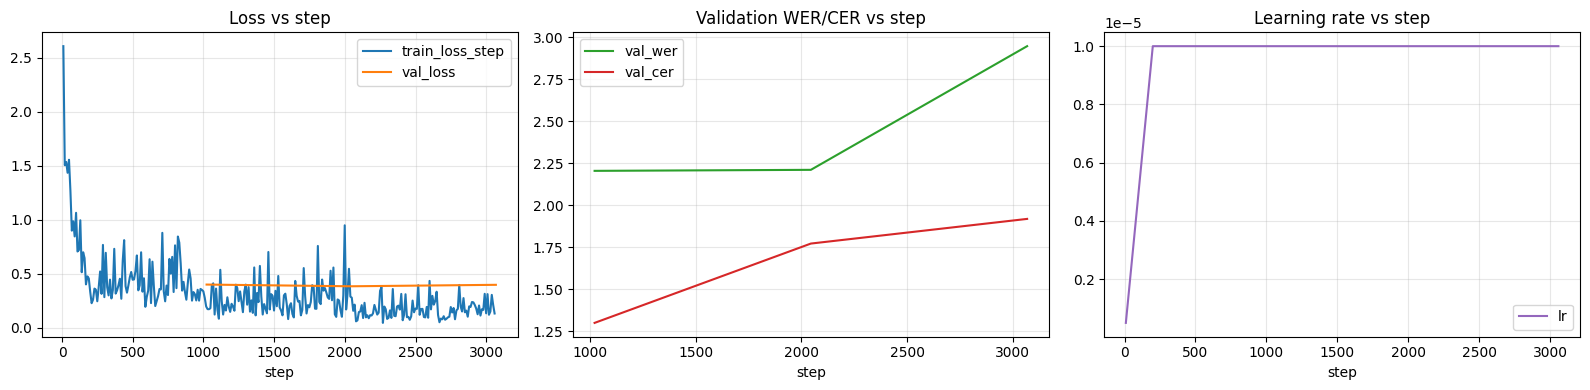

,epoch_int,train_loss,val_loss,val_wer,val_cer
0,-1,NaN,NaN,NaN,NaN
1,0,0.547830,0.400228,2.204483,1.298958
2,1,0.269499,0.384396,2.210536,1.771423
3,2,0.162463,0.397908,2.947122,1.918318
4,3,NaN,NaN,NaN,NaN


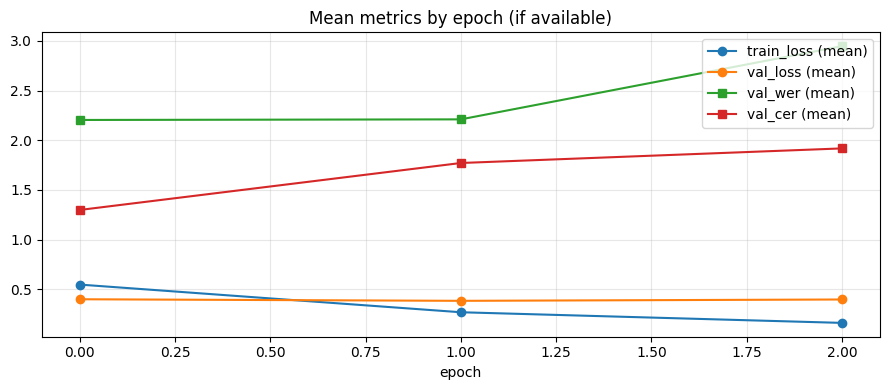

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_csv = None
logs_root = out_dir / 'logs'
if logs_root.exists():
    for p in logs_root.rglob('metrics.csv'):
        metrics_csv = p
        break

print('metrics_csv:', metrics_csv)
df = pd.read_csv(metrics_csv) if metrics_csv else None
if df is not None:
    # Lightning writes a wide CSV: each row only has fields for that event, so raw rows are sparse.
    # Forward-fill along the full timeline for a readable tail preview (not for exporting metrics).
    _preview = df.ffill().tail(20)
    _preview = _preview.where(_preview.notna(), '')
    display(_preview)
else:
    display('No metrics.csv')

if df is not None and 'step' in df.columns:
    train_step_col = next((c for c in ('train_loss_step', 'train_loss', 'train_loss_epoch') if c in df.columns), None)

    # 1) Loss + val metrics vs step
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    if train_step_col is not None:
        sub = df.dropna(subset=[train_step_col])
        axes[0].plot(sub['step'], sub[train_step_col], label=train_step_col, color='C0')
    if 'val_loss' in df.columns:
        sub = df.dropna(subset=['val_loss'])
        axes[0].plot(sub['step'], sub['val_loss'], label='val_loss', color='C1')
    axes[0].set_title('Loss vs step')
    axes[0].set_xlabel('step')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if 'val_wer' in df.columns:
        sub = df.dropna(subset=['val_wer'])
        axes[1].plot(sub['step'], sub['val_wer'], label='val_wer', color='C2')
    if 'val_cer' in df.columns:
        sub = df.dropna(subset=['val_cer'])
        axes[1].plot(sub['step'], sub['val_cer'], label='val_cer', color='C3')
    axes[1].set_title('Validation WER/CER vs step')
    axes[1].set_xlabel('step')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    if 'lr-AdamW' in df.columns:
        sub = df.dropna(subset=['lr-AdamW'])
        axes[2].plot(sub['step'], sub['lr-AdamW'], label='lr', color='C4')
    elif 'learning_rate' in df.columns:
        sub = df.dropna(subset=['learning_rate'])
        axes[2].plot(sub['step'], sub['learning_rate'], label='lr', color='C4')
    axes[2].set_title('Learning rate vs step')
    axes[2].set_xlabel('step')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # 2) Epoch-level view (if epoch column exists)
    if 'epoch' in df.columns:
        ep = df.copy()
        ep['epoch_int'] = ep['epoch'].fillna(-1).astype(float).astype(int)

        agg_kwargs = {}
        if 'train_loss_epoch' in ep.columns:
            agg_kwargs['train_loss'] = ('train_loss_epoch', 'mean')
        elif 'train_loss' in ep.columns:
            agg_kwargs['train_loss'] = ('train_loss', 'mean')
        elif 'train_loss_step' in ep.columns:
            agg_kwargs['train_loss'] = ('train_loss_step', 'mean')
        if 'val_loss' in ep.columns:
            agg_kwargs['val_loss'] = ('val_loss', 'mean')
        if 'val_wer' in ep.columns:
            agg_kwargs['val_wer'] = ('val_wer', 'mean')
        if 'val_cer' in ep.columns:
            agg_kwargs['val_cer'] = ('val_cer', 'mean')

        if agg_kwargs:
            ep2 = ep.groupby('epoch_int', as_index=False).agg(**agg_kwargs)
        else:
            ep2 = ep.groupby('epoch_int', as_index=False).size().reset_index(name='n_rows')
        display(ep2)

        fig, ax = plt.subplots(figsize=(9, 4))
        if 'train_loss' in ep2.columns:
            ax.plot(ep2['epoch_int'], ep2['train_loss'], marker='o', label='train_loss (mean)')
        if 'val_loss' in ep2.columns:
            ax.plot(ep2['epoch_int'], ep2['val_loss'], marker='o', label='val_loss (mean)')
        if 'val_wer' in ep2.columns:
            ax.plot(ep2['epoch_int'], ep2['val_wer'], marker='s', label='val_wer (mean)')
        if 'val_cer' in ep2.columns:
            ax.plot(ep2['epoch_int'], ep2['val_cer'], marker='s', label='val_cer (mean)')
        ax.set_title('Mean metrics by epoch (if available)')
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


## 5) Final test ONLY on `test_lines` (WER/CER)


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_cer          │    1.8039106130599976     │
│         test_wer          │     1.852233648300171     │
└───────────────────────────┴───────────────────────────┘

[{'test_wer': 1.852233648300171, 'test_cer': 1.8039106130599976}]

Saved: /kaggle/working/asr_out/metrics.json


,split,WER,CER
0,val (остання епоха),2.947122,1.918318
1,test (holdout),1.852234,1.803911


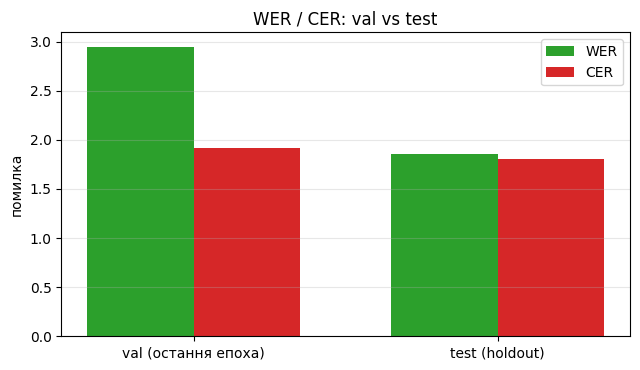

In [17]:
test_res = trainer.test(model=model, datamodule=dm, ckpt_path=ckpt.best_model_path or None)
display(test_res)

payload = {
    'cfg': asdict(cfg),
    'split_sizes': dm.split_sizes,
    'best_checkpoint': ckpt.best_model_path,
    'test_results': test_res,
}

with (out_dir / 'metrics.json').open('w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print('Saved:', str(out_dir / 'metrics.json'))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Зведена таблиця WER/CER: останній val (з metrics.csv) і test (holdout)
val_wer = val_cer = np.nan
_logs = out_dir / 'logs'
_mc = next(_logs.rglob('metrics.csv'), None) if _logs.exists() else None
if _mc is not None:
    _dfm = pd.read_csv(_mc)
    _last = _dfm.ffill().iloc[-1]
    if pd.notna(_last.get('val_wer')):
        val_wer = float(_last['val_wer'])
    if pd.notna(_last.get('val_cer')):
        val_cer = float(_last['val_cer'])

test_wer = test_cer = np.nan
if test_res and isinstance(test_res[0], dict):
    if test_res[0].get('test_wer') is not None:
        test_wer = float(test_res[0]['test_wer'])
    if test_res[0].get('test_cer') is not None:
        test_cer = float(test_res[0]['test_cer'])

summary_df = pd.DataFrame([
    {'split': 'val (остання епоха)', 'WER': val_wer, 'CER': val_cer},
    {'split': 'test (holdout)', 'WER': test_wer, 'CER': test_cer},
])
display(summary_df)

_fig, _ax = plt.subplots(figsize=(6.5, 3.8))
_x = np.arange(len(summary_df))
_bw = 0.35
_ax.bar(_x - _bw / 2, summary_df['WER'], width=_bw, label='WER', color='C2')
_ax.bar(_x + _bw / 2, summary_df['CER'], width=_bw, label='CER', color='C3')
_ax.set_xticks(_x)
_ax.set_xticklabels(summary_df['split'])
_ax.set_ylabel('помилка')
_ax.set_title('WER / CER: val vs test')
_ax.legend()
_ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
